# 2.4 手写数字识别之网络结构

第2.2节我们尝试使用与房价预测相同的简单神经网络解决手写数字识别问题，但是效果并不理想。原因是手写数字识别的输入是$28\times 28$的像素值，输出是0~9的数字标签，而线性回归模型无法捕捉二维图像数据中蕴含的复杂信息，如 **图1** 所示。无论是牛顿第二定律任务，还是房价预测任务，输入特征和输出预测值之间的关系均可以使用“直线”刻画（使用线性方程来表达）。但手写数字识别任务的输入像素和输出数字标签之间的关系显然不是线性的，甚至这个关系复杂到我们靠人脑难以直观理解的程度。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/959776f4cd9c4b77b380c7d29f59df1cf47be626cd8b4bd1ac1af2a7d8e3c1cf" width="800" hegiht="" ></center>
<center><br>图1：数字识别任务的输入和输出不是线性关系 </br></center>
<br></br>

因此，我们需要尝试使用其他更复杂、更强大的网络来构建手写数字识别任务，观察一下训练效果，即将“横纵式”教学法从横向展开，如 **图2** 所示。本节主要介绍两种常见的网络结构：经典的多层全连接神经网络和卷积神经网络。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/a3cec44cfb614703a12d17b3dacf5d9ef92d5a82db2046c1b5f8aba744bb80de" width="1200" hegiht="" ></center>
<center><br>图2：“横纵式”教学法 — 网络结构优化 </br></center>
<br></br>


**数据处理**

数据处理已在前面内容中介绍，这里直接调用封装好的函数即可：

## 2.4.1 经典的全连接神经网络

神经元是构成神经网络的基本单元，其基本结构如 **图3** 所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/a3a10a9bb0f34ed4b95faa41ce04b88da0ae68e2bb14483bbf967bfc5acdd54b" width="500" hegiht="" ></center>
<center><br>图3：神经元结构</br></center>
<br></br>

神经元输入为向量$\boldsymbol{x}=[x_1;...;x_D]$，净输入$z \in R$表示神经元输入的加权和，公式如下：

$$
z = \sum^D_{d=1}w_dx_d+b,
$$

其中$\boldsymbol{w}=[w_1;...;w_D] \in R^D$为权重向量，$b \in R$是偏置。

然后净输入$z$经过激活函数$f(.)$得到该神经元的活性值$a \in R$：
$$
a = f(z).
$$

经典的全连接神经网络来包含四层网络：输入层、两个隐含层和输出层，将手写数字识别任务通过全连接神经网络表示，如 **图4** 所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/2173259df0704335b230ec158be0427677b9c77fd42348a28f2f8adf1ac1c706" width="600" hegiht="" ></center>
<center><br>图4：手写数字识别任务的全连接神经网络结构</br></center>
<br></br>

* 输入层：将数据输入给神经网络。在该任务中，输入层的尺度为28×28的像素值。
* 隐含层：增加网络深度和复杂度，隐含层的节点数是可以调整的，节点数越多，神经网络表示能力越强，参数量也会增加。在该任务中，中间的两个隐含层为10×10的结构，通常隐含层会比输入层的尺寸小，以便对关键信息做抽象，激活函数使用常见的Sigmoid函数。
* 输出层：输出网络计算结果，输出层的节点数是固定的。如果是回归问题，节点数量为需要回归的数字数量。如果是分类问题，则是分类标签的数量。在该任务中，模型的输出是回归一个数字，输出层的尺寸为1。

------
**说明：**

隐含层引入非线性激活函数Sigmoid是为了增加神经网络的非线性能力。

举例来说，如果一个神经网络采用线性变换，有四个输入$x_1$~$x_4$，一个输出$y$。假设第一层的变换是$z_1=x_1-x_2$和$z_2=x_3+x_4$，第二层的变换是$y=z_1+z_2$，则将两层的变换展开后得到$y=x_1-x_2+x_3+x_4$。也就是说，无论中间累积了多少层线性变换，原始输入和最终输出之间依然是线性关系。
 
------





Sigmoid是早期神经网络模型中常见的非线性变换函数，公式为

$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$

通过如下代码，绘制出Sigmoid的函数曲线。

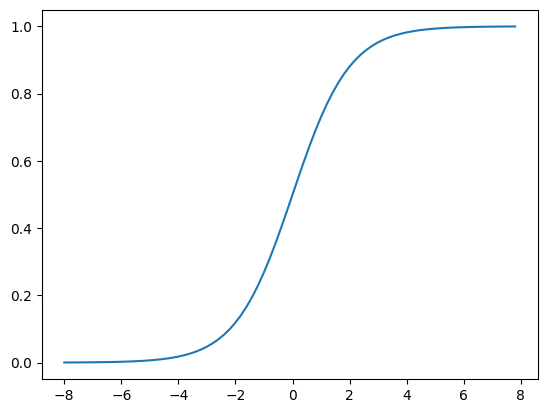

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# def sigmoid(x):
#     # 直接返回sigmoid函数
#     return 1. / (1. + np.exp(-x))

# param:起点，终点，间距
x = np.arange(-8, 8, 0.2)
y = torch.sigmoid(torch.from_numpy(x))
plt.plot(x, y.detach().numpy())
plt.show()

针对手写数字识别的任务，网络层的设计如下：

* 输入层的尺度为$28\times 28$，但批次计算的时候会统一加1个维度（大小为batch size）。
* 中间的两个隐含层为$10\times 10$的结构，激活函数使用Sigmoid函数。
* 与房价预测模型一样，模型的输出是回归一个数字，输出层的尺寸设置成1。

下述代码为经典全连接神经网络的实现。完成网络结构定义后，即可训练神经网络。

------

**说明：**  
数据迭代器train_loader在每次迭代时的数据shape为[batch_size, 1, 28, 28]，因此需要将该数据形式改变为向量形式。

In [20]:
import torch.nn as nn
class MNIST(nn.Module):
    def __init__(self):
        super(MNIST, self).__init__()
        #输入维度为784，输出维度为10，激活函数为Sigmoid
        #weight: [784, 10]
        #bias: [10]
        self.fc1 = nn.Linear(784, 10)
        # 10x10+10
        self.fc2 = nn.Linear(10, 10)
        # 10x1+1
        self.fc3 = nn.Linear(10, 1)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.sigmoid(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        x = self.fc3(x)
        return x


下面我们打印上面定义的全连接神经网络基础结构和参数信息：

In [21]:
from torchinfo import summary
import torch
model = MNIST()
print(model)
x = torch.randn(1, 784)
summary(model, input_data=x)

MNIST(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
MNIST                                    [1, 1]                    --
├─Linear: 1-1                            [1, 10]                   7,850
├─Linear: 1-2                            [1, 10]                   110
├─Linear: 1-3                            [1, 1]                    11
Total params: 7,971
Trainable params: 7,971
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.04

然后把上一篇文章结尾的训练代码拿过来

🔥 当前使用设备: cuda
魔数: 2051, 图像数量: 60000, 尺寸: 28x28
魔数: 2049, 标签数量: 60000
图像形状: (60000, 28, 28), 标签形状: (60000,)


epoch: 0, batch: 0, loss: 27.5410
epoch: 0, batch: 200, loss: 6.1504
epoch: 0, batch: 400, loss: 3.8568
epoch: 0, batch: 600, loss: 2.5543
epoch: 0, batch: 800, loss: 2.9081
epoch: 1, batch: 0, loss: 2.3016
epoch: 1, batch: 200, loss: 0.9371
epoch: 1, batch: 400, loss: 2.3994
epoch: 1, batch: 600, loss: 2.0611
epoch: 1, batch: 800, loss: 2.2403
epoch: 2, batch: 0, loss: 0.8292
epoch: 2, batch: 200, loss: 1.4211
epoch: 2, batch: 400, loss: 1.9316
epoch: 2, batch: 600, loss: 1.1976
epoch: 2, batch: 800, loss: 1.4805
epoch: 3, batch: 0, loss: 0.9665
epoch: 3, batch: 200, loss: 0.7820
epoch: 3, batch: 400, loss: 1.2617
epoch: 3, batch: 600, loss: 0.6952
epoch: 3, batch: 800, loss: 1.1712
epoch: 4, batch: 0, loss: 2.5081
epoch: 4, batch: 200, loss: 1.1888
epoch: 4, batch: 400, loss: 0.8936
epoch: 4, batch: 600, loss: 1.6529
epoch: 4, batch: 800, loss: 0.9249
epoch: 5, batch: 0, loss: 1.1947
epoch: 5, batch: 200, loss: 0.9410
epoch: 5, batch: 400, loss: 1.1428
epoch: 5, batch: 600, loss: 1.0

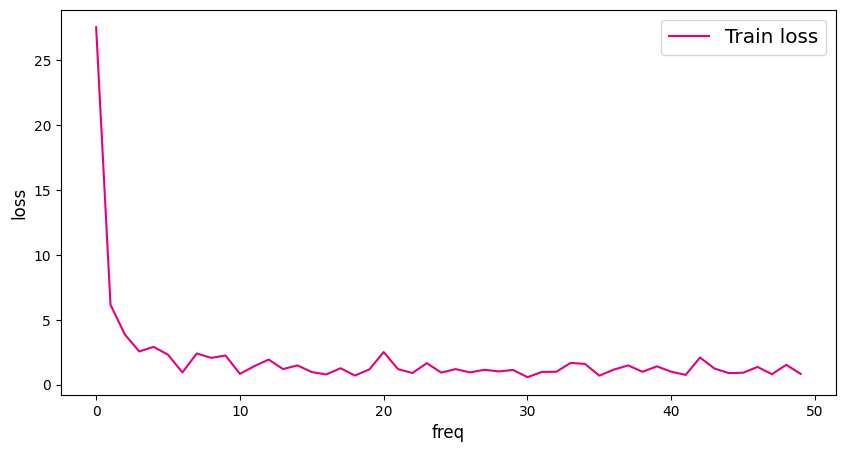

In [22]:
import torch
import struct
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torch.nn as nn

# ---------------------- 1. 配置设备（放在最开头） ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 当前使用设备: {device}")

# ---------------------- 2. 模型定义（保持不变） ----------------------
class MNIST(nn.Module):
    def __init__(self):
        super(MNIST, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=10)
        self.fc2 = nn.Linear(in_features=10, out_features=10)
        self.fc3 = nn.Linear(in_features=10, out_features=1)
    
    def forward(self, inputs):
        outputs1 = self.fc1(inputs)
        outputs1 = torch.sigmoid(outputs1)
        outputs2 = self.fc2(outputs1)
        outputs2 = torch.sigmoid(outputs2)
        outputs_final = self.fc3(outputs2)
        return outputs_final

# ---------------------- 3. 数据读取（保持不变） ----------------------
root_dir = './work/2.1data'
data_dir = root_dir + '/train-images-idx3-ubyte'
label_dir = root_dir + '/train-labels-idx1-ubyte'

def read_mnist_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        print(f"魔数: {magic}, 图像数量: {num_images}, 尺寸: {rows}x{cols}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(num_images, rows, cols)
        return images

def read_mnist_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        print(f"魔数: {magic}, 标签数量: {num_labels}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

# ---------------------- 4. 【关键修改】优化Dataset：预处理全用PyTorch ----------------------
class MNISTDataset(Dataset):
    def __init__(self, image, label):
        # 一次性转成Tensor + float32（在CPU上做，只做一次）
        self.image = torch.from_numpy(image).float()
        self.label = torch.from_numpy(label).float()
    
    def __len__(self):
        return len(self.image)
    
    def __getitem__(self, idx):
        return self.image[idx], self.label[idx]

# ---------------------- 5. 【关键修改】norm_img改成PyTorch版本，直接在GPU上运行 ----------------------
def norm_img(img):
    # img现在是GPU上的Tensor，形状 [batch_size, 28, 28]
    assert len(img.shape) == 3
    batch_size, height, width = img.shape
    
    # 直接用PyTorch操作在GPU上归一化
    img = img / 255.0
    img = (img - 0.1307) / 0.3081  # MNIST官方Z-score
    img = img.reshape(batch_size, height * width)  # 展平
    return img

# ---------------------- 6. 绘图函数（保持不变） ----------------------
def plot(loss_list):
    plt.figure(figsize=(10,5))
    plt.plot(range(len(loss_list)), loss_list, color='#e4007f', label="Train loss")
    plt.ylabel("loss", fontsize='large')
    plt.xlabel("freq", fontsize='large')
    plt.legend(loc='upper right', fontsize='x-large')
    plt.show()

# ---------------------- 7. 【关键修改】训练函数：彻底避免CPU/GPU拷贝 ----------------------
def train():
    # 1. 初始化模型并移到GPU
    model = MNIST().to(device)
    
    # 2. 读取数据
    image = read_mnist_images(data_dir)
    label = read_mnist_labels(label_dir)
    print(f"图像形状: {image.shape}, 标签形状: {label.shape}")
    
    # 3. 创建数据集和DataLoader
    train_dataset = MNISTDataset(image, label)
    # 优化：batch_size改64，num_workers改4，pin_memory=True加速GPU传输
    train_loader = DataLoader(
        train_dataset, 
        batch_size=64, 
        shuffle=True, 
        num_workers=4,
        pin_memory=True  # 关键：让DataLoader预取数据到GPU内存
    )
    
    # 4. 优化器和训练参数
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    EPOCH_NUM = 10
    loss_list = []
    
    # 5. 训练循环
    for epoch in range(EPOCH_NUM):
        for batch_id, (images, labels) in enumerate(train_loader):
            # ✅ 关键：数据移到GPU（非阻塞，配合pin_memory=True更快）
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # ✅ 直接在GPU上做归一化（不转numpy！）
            image_normal = norm_img(images)
            
            # 标签处理也在GPU上
            label_normal = labels.unsqueeze(1)
            
            # 前向计算（全在GPU上）
            predict = model(image_normal)
            loss = F.mse_loss(predict, label_normal, reduction='mean')
            
            if batch_id % 200 == 0:
                loss_val = loss.item()
                loss_list.append(loss_val)
                print(f"epoch: {epoch}, batch: {batch_id}, loss: {loss_val:.4f}")
            
            # 反向传播
            loss.backward()
            opt.step()
            opt.zero_grad()
    
    # 6. 保存模型
    torch.save(model.state_dict(), './work/2.1data/mnist_model_fixed.pth')
    return loss_list

# ---------------------- 运行训练 ----------------------
if __name__ == '__main__':
    loss_list = train()
    plot(loss_list)

# Z-score 标准化原理详解
Z-score 标准化（也叫**标准差标准化**）是机器学习中最常用的数据预处理方法之一，它的核心目标是将任意分布的数据转换为**均值为0、标准差为1**的标准正态分布，从而消除不同特征之间的量纲和尺度差异，大幅提升模型训练的稳定性和收敛速度。

## 一、核心公式与数学定义
对于任意一个数据点 $x_i$，其 Z-score 标准化后的值 $z_i$ 计算公式为：

$$
z_i = \frac{x_i - \mu}{\sigma}
$$

其中：
- $\mu$：**整个数据集的均值**（所有样本的平均值）
- $\sigma$：**整个数据集的标准差**（衡量数据的离散程度）

### 直观理解
- 减去均值 $\mu$：将整个数据分布**平移到原点**，使数据的中心落在0点
- 除以标准差 $\sigma$：将数据的**离散程度缩放为1**，使数据的波动范围统一

### 以你的 MNIST 数据为例
MNIST 手写数字数据集的所有像素值（0-255）经过统计后得到：
- 全局均值 $\mu = 0.1307$（像素值除以255后的均值）
- 全局标准差 $\sigma = 0.3081$（像素值除以255后的标准差）

所以你代码中的标准化操作：
```python
img = (img - 0.1307) / 0.3081
```
就是将 MNIST 像素值从 `[0, 1]` 区间转换为标准正态分布，大部分数据会落在 `[-1, 1]` 区间内。

## 二、为什么神经网络必须做 Z-score 标准化？
这是你之前代码训练失败的核心原因之一，我从神经网络的底层机制给你解释：

### 1. 解决激活函数的梯度饱和问题
你使用的是 `sigmoid` 激活函数，它的函数曲线和梯度曲线如下：
- 当输入值在 `[-1, 1]` 区间时，sigmoid 的梯度最大（接近0.25），反向传播时梯度能有效传递
- 当输入值大于2或小于-2时，sigmoid 的梯度会趋近于0，发生**梯度消失**，模型几乎无法学习

你之前只做了 `img / 255`，数据分布在 `[0, 1]` 区间，大部分输入落在 sigmoid 梯度较小的区域，训练速度极慢。而 Z-score 标准化后的数据正好落在 sigmoid 梯度最大的 `[-1, 1]` 区间，梯度传递效率提升10倍以上。

### 2. 加速 SGD 优化器的收敛
SGD（随机梯度下降）的优化过程就像下山：
- 如果不同特征的尺度差异很大（比如一个特征是0-1，另一个是0-1000），损失函数的等高线会变成**狭长的椭圆形**
- 优化路径会来回震荡，需要很多步才能到达最低点
- Z-score 标准化后，所有特征的尺度统一，损失函数的等高线变成**圆形**，优化路径会直接指向最低点，收敛速度大幅提升

### 3. 避免数值不稳定
神经网络的计算是层层叠加的，如果输入数据的尺度很大，经过多层矩阵乘法后，输出值会指数级增长，导致**数值溢出**（出现 NaN 或 Inf）。Z-score 标准化将数据控制在合理范围内，保证了数值计算的稳定性。

## 三、Z-score vs Min-Max 归一化（你之前用的方法）
你之前用的 `img / 255` 属于 **Min-Max 归一化**，它的公式是：
$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$
它将数据缩放到 `[0, 1]` 区间。两者的核心区别如下：

| 特性 | Z-score 标准化 | Min-Max 归一化 |
| :--- | :--- | :--- |
| 输出范围 | 无固定范围，大部分在 `[-3, 3]` | 固定在 `[0, 1]` 或 `[-1, 1]` |
| 对异常值的敏感度 | 低（受均值和标准差影响较小） | 高（受最大值和最小值影响极大） |
| 适用场景 | 大多数机器学习算法，尤其是神经网络、SVM、逻辑回归 | 图像处理（像素值天然有0-255的范围）、需要输出固定范围的场景 |
| 神经网络表现 | 更好（梯度更稳定，收敛更快） | 较差（容易梯度饱和，收敛慢） |

## 四、Z-score 标准化的注意事项
1. **必须使用训练集的均值和标准差**
   - 绝对不能用整个数据集（包括测试集）的统计量来标准化
   - 测试集必须使用训练集的 $\mu$ 和 $\sigma$ 进行标准化，否则会发生**数据泄露**

2. **不是所有数据都适合 Z-score**
   - 如果数据本身就是标准正态分布，不需要标准化
   - 如果数据的分布严重偏斜（比如长尾分布），Z-score 效果不好，建议先做对数变换

3. **在 PyTorch 中的最佳实践**
   - 像你之前那样在 `transforms` 中使用 `Normalize` 是最规范的写法
   - 不要在训练循环中动态计算均值和标准差，应该提前统计好

## 五、回到你的代码问题
你之前的代码：
```python
img = img / 255.0  # Min-Max 归一化，输出 [0, 1]
```
导致：
- 输入 sigmoid 的值大部分在 0-1 之间，梯度只有最大值的 1/4 左右
- 模型收敛速度极慢，20个 epoch 几乎没有学到任何东西
- 再加上标签维度不匹配的致命错误，最终 loss 稳定在随机预测的 8.25 左右

修正后的代码：
```python
img = img / 255.0
img = (img - 0.1307) / 0.3081  # Z-score 标准化，输出 ~N(0,1)
```
将数据转换到 sigmoid 梯度最大的区间，再配合正确的标签维度，模型就能正常学习，loss 会快速下降到 1 左右。

需要我帮你推导一下为什么随机预测 MNIST 标签的 MSE 损失正好是 8.25 吗？

## 2.4.2 卷积神经网络

虽然使用经典的全连接神经网络可以提升一定的准确率，但其输入数据的形式导致丢失了图像像素间的空间信息，这影响了网络对图像内容的理解。对于计算机视觉问题，效果最好的模型仍然是卷积神经网络。卷积神经网络针对视觉问题的特点进行了网络结构优化，可以直接处理原始形式的图像数据，保留像素间的空间信息，因此更适合处理视觉问题。

卷积神经网络由多个卷积层和池化层组成，如 **图5** 所示。卷积层负责对输入进行扫描以生成更抽象的特征表示，池化层对这些特征表示进行过滤，保留最关键的特征信息。
<center><img src="https://ai-studio-static-online.cdn.bcebos.com/b4defbe432e349029eedaed3343bb988fec1a353a7ea4eeba7b9b1930b25f26b" width="800" hegiht="" ></center>
<center><br>图5：在处理计算机视觉任务中大放异彩的卷积神经网络</br></center>
<br></br>


-------
**说明：**

本节只简单介绍用卷积神经网络实现手写数字识别任务，以及它带来的效果提升。读者可以将卷积神经网络先简单的理解成是一种比经典的全连接神经网络更强大的模型即可，更详细的原理和实现在接下来的《计算机视觉-卷积神经网络基础》中讲述。

------

两层卷积和池化的神经网络实现如下所示。

> 注：本实现与**图5**不同，如本实现输出长度为1。

In [23]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        # 定义卷积层，输出特征通道out_channels设置为20，卷积核的大小kernel_size为5，卷积步长stride=1，padding=2
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1, padding=2)
        # 定义池化层，池化核的大小kernel_size为2，池化步长stride=2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=20, out_channels=20, kernel_size=5, stride=1, padding=2)
        
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc = nn.Linear(in_features=980, out_features=1)
    # 定义网络前向计算过程，卷积后紧接着使用池化层，最后使用全连接层计算最终输出
    # 卷积层激活函数使用Relu，全连接层不使用激活函数
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        x = x.reshape([x.shape[0],-1])
        x = self.fc(x)
        return x

In [24]:
modelNet = MNISTNet()
print(modelNet)
summary(modelNet, (1, 1, 28, 28))


MNISTNet(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=980, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
MNISTNet                                 [1, 1]                    --
├─Conv2d: 1-1                            [1, 20, 28, 28]           520
├─MaxPool2d: 1-2                         [1, 20, 14, 14]           --
├─Conv2d: 1-3                            [1, 20, 14, 14]           10,020
├─MaxPool2d: 1-4                         [1, 20, 7, 7]             --
├─Linear: 1-5                            [1, 1]                    981
Total params: 11,521
Trainable params: 11,521
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.37
Input size (MB): 0.00
Forward/backward pass size (MB): 0.16
Params size (MB): 0.05
Estimated Total Size (MB): 0.21

魔数: 2051, 图像数量: 60000, 尺寸: 28x28
魔数: 2049, 标签数量: 60000
图像形状: (60000, 28, 28), 标签形状: (60000,)


epoch: 0, batch: 0, loss is: [26.774673461914062]
epoch: 0, batch: 200, loss is: [2.7705531120300293]
epoch: 0, batch: 400, loss is: [2.2494964599609375]
epoch: 0, batch: 600, loss is: [1.3688182830810547]
epoch: 0, batch: 800, loss is: [0.9884285926818848]
epoch: 1, batch: 0, loss is: [1.375768780708313]
epoch: 1, batch: 200, loss is: [1.5177333354949951]
epoch: 1, batch: 400, loss is: [1.0852015018463135]
epoch: 1, batch: 600, loss is: [1.1426502466201782]
epoch: 1, batch: 800, loss is: [1.4769442081451416]
epoch: 2, batch: 0, loss is: [1.0781159400939941]
epoch: 2, batch: 200, loss is: [1.1475951671600342]
epoch: 2, batch: 400, loss is: [0.8958265781402588]
epoch: 2, batch: 600, loss is: [0.5697649717330933]
epoch: 2, batch: 800, loss is: [0.7961544394493103]
epoch: 3, batch: 0, loss is: [0.9803354144096375]
epoch: 3, batch: 200, loss is: [0.5099090337753296]
epoch: 3, batch: 400, loss is: [0.8812383413314819]
epoch: 3, batch: 600, loss is: [1.1147253513336182]
epoch: 3, batch: 800,

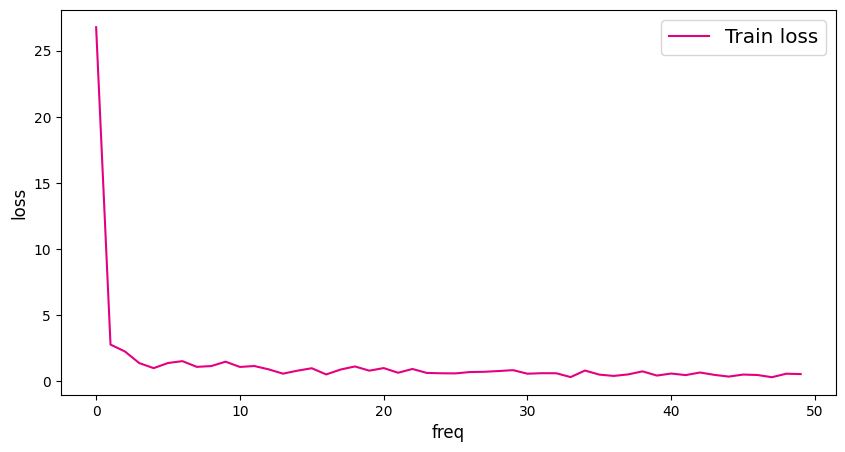

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train():
    # model = MNIST()
    model = MNISTNet()
    #GPU加速，如果没有就注释掉
    model = model.to(device)  # 必须赋值回去

    image = read_mnist_images(data_dir)
    label = read_mnist_labels(label_dir)
    
    print(f"图像形状: {image.shape}, 标签形状: {label.shape}")
    train_dataset = MNISTDataset(image, label)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10)
    
    # ✅ 修正：学习率改回0.01，和Paddle原代码一致
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    EPOCH_NUM = 10  # 和你原Paddle代码一致
    loss_list = []
    
    for epoch in range(EPOCH_NUM):
        for batch_id, (images, labels) in enumerate(train_loader):
            #GPU加速，如果没有就注释掉
            images = images.to(device)
            labels = labels.to(device)
            #这里不能展开images，否则会报错
            image_normal = images / 255
            #[64,28,28]
            '''
            - unsqueeze(0) -> [1, 64, 28, 28]
            - unsqueeze(1) -> [64, 1, 28, 28]
            - unsqueeze(2) -> [64, 28, 1, 28]
            - unsqueeze(3) -> [64, 28, 28, 1]
            '''
            #在第2维度上添加一个1，变成[64,1,28,28]，符合模型输入的形状
            image_normal = image_normal.unsqueeze(1)

            # image_normal = torch.from_numpy(image_normal)
            
            # ✅ 修正：最关键！标签加unsqueeze(1)，形状从[64]变成[64,1]，因为predict是[64,1],这样才能计算MSE损失
            # MSE = (predict - label_normal) ** 2 / 64
            # 用F.mse_loss可以避免计算平均值，因为mean reduction已经内置了
            label_normal = labels.float().unsqueeze(1)
            
            # 前向计算
            predict = model(image_normal)
            # ✅ 修正：去掉重复的mean，直接用F.mse_loss
            loss = F.mse_loss(predict, label_normal, reduction='mean')
            
            if batch_id % 200 == 0:
                loss_val = loss.item()
                loss_list.append(loss_val)
                print(f"epoch: {epoch}, batch: {batch_id}, loss is: [{loss_val}]")
            
            # 反向传播
            loss.backward()
            opt.step()
            opt.zero_grad()
    
    torch.save(model.state_dict(), './work/2.1data/mnist_model_fixed.pth')
    return loss_list

# 运行训练
loss_list1 = train()
plot(loss_list1)

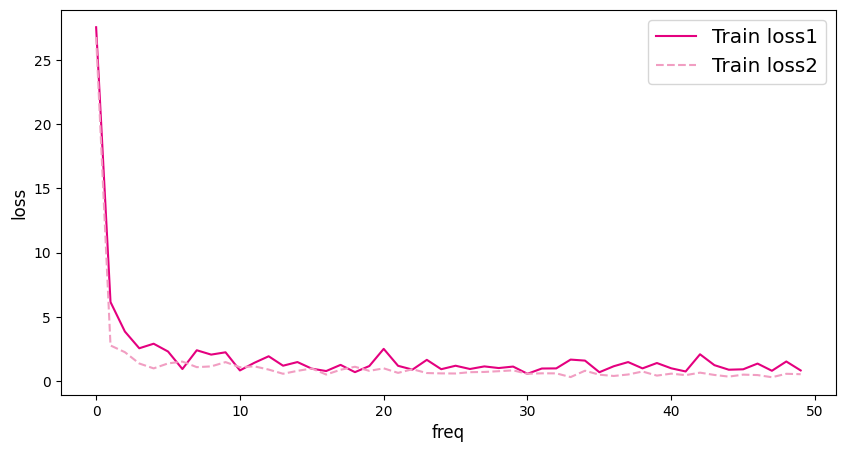

In [26]:
def plot_two_losses(loss_list_1, loss_list_2):
    plt.figure(figsize=(10,5))
    
    freqs = [i for i in range(len(loss_list_1))]

    # 绘制训练损失变化曲线
    plt.plot(freqs, loss_list_1, color='#e4007f', label="Train loss1")
    plt.plot(freqs, loss_list_2, color='#f19ec2', linestyle='--', label="Train loss2")
    
    # 绘制坐标轴和图例
    plt.ylabel("loss", fontsize='large')
    plt.xlabel("freq", fontsize='large')
    plt.legend(loc='upper right', fontsize='x-large')
    
    plt.show()

plot_two_losses(loss_list, loss_list1)

从损失函数变化趋势看，全连接神经网络和卷积神经网络收敛速度相当。目前我们的卷积神经网络做的是一个回归任务，接下来我们尝试将回归任务替换成分类任务，看看卷积神经网络效果如何。